## 1. Install Dependencies

In [ ]:
!pip install torch numpy matplotlib scikit-learn tqdm

## 2. Imports & Setup

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)
np.random.seed(42)

print("Device:", device)

Device: cuda


## 3. Dataset Loading

Load all three WS22 molecule files. The files can be downloaded from Zenodo:
- `ws22_acrolein.npz`
- `ws22_ohbdi.npz`
- `ws22_sma.npz`

Update the paths below to match your Google Drive / local file locations.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# UPDATE THESE PATHS to match your file locations
# e.g. "/content/drive/MyDrive/.../ws22_acrolein.npz"
# ============================================================
DATASET_PATHS = {
    "acrolein": "/ML_Che_projects/7032334/ws22_acrolein.npz",
    "ohbdi":    "/ML_Che_projects/7032334/ws22_o-hbdi.npz",
    "sma":      "/ML_Che_projects/7032334/ws22_sma.npz",
}


def load_ws22(path):
    """Load a WS22 .npz file and return Z, R, E, F arrays."""
    data = np.load(path)
    Z = data["Z"]   # atomic numbers, shape (n_atoms,)
    R = data["R"]   # positions,      shape (n_configs, n_atoms, 3)
    E = data["E"]   # energies,        shape (n_configs,) or (n_configs, 1)
    F = data["F"]   # forces,          shape (n_configs, n_atoms, 3)
    E = E.squeeze()  # ensure 1-D
    return Z, R, E, F


datasets = {}
for mol, path in DATASET_PATHS.items():
    Z, R, E, Frc = load_ws22(path)
    datasets[mol] = {"Z": Z, "R": R, "E": E, "F": Frc}
    print(f"{mol:10s} | configs: {R.shape[0]:6d} | atoms: {Z.shape[0]} | Z: {np.unique(Z)}")

acrolein   | configs: 120000 | atoms: 8 | Z: [1 6 8]
ohbdi      | configs: 120000 | atoms: 22 | Z: [1 6 7 8]
sma        | configs: 120040 | atoms: 19 | Z: [1 6 7 8]


## 4. Dataset Class & DataLoaders

In [ ]:
class WS22Dataset(torch.utils.data.Dataset):
    """
    Dataset for one WS22 molecule.
    Returns (pos, energy, force, atomic_numbers) per sample.
    Energy is normalised (zero-mean, unit-variance) over the training split.
    """

    def __init__(self, R, E, forces, Z, indices, E_mean=None, E_std=None):
        self.R      = R[indices]
        self.E_raw  = E[indices]
        self.forces = forces[indices]
        self.Z      = Z  # global atomic-number array — same for every config

        # Normalise energies (fit on train split only, then reuse for val/test)
        if E_mean is None:
            self.E_mean = self.E_raw.mean()
            self.E_std  = self.E_raw.std()
        else:
            self.E_mean = E_mean
            self.E_std  = E_std

        self.E_norm = (self.E_raw - self.E_mean) / self.E_std

    def __len__(self):
        return len(self.R)

    def __getitem__(self, idx):
        pos    = torch.tensor(self.R[idx],      dtype=torch.float32)
        energy = torch.tensor(self.E_norm[idx], dtype=torch.float32)
        force  = torch.tensor(self.forces[idx], dtype=torch.float32)
        z      = torch.tensor(self.Z,           dtype=torch.long)
        return pos, energy, force, z


def make_loaders(mol_data, batch_size=32, test_size=0.1, val_size=0.1, seed=42):
    """Split indices, build datasets and DataLoaders for one molecule."""
    Z, R, E, forces = mol_data["Z"], mol_data["R"], mol_data["E"], mol_data["F"]
    idx = np.arange(len(R))

    train_idx, test_idx = train_test_split(idx, test_size=test_size, random_state=seed)
    train_idx, val_idx  = train_test_split(train_idx, test_size=val_size,  random_state=seed)

    train_ds = WS22Dataset(R, E, forces, Z, train_idx)
    val_ds   = WS22Dataset(R, E, forces, Z, val_idx,
                           E_mean=train_ds.E_mean, E_std=train_ds.E_std)
    test_ds  = WS22Dataset(R, E, forces, Z, test_idx,
                           E_mean=train_ds.E_mean, E_std=train_ds.E_std)

    loaders = {
        "train": torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        "val":   torch.utils.data.DataLoader(val_ds,   batch_size=batch_size),
        "test":  torch.utils.data.DataLoader(test_ds,  batch_size=batch_size),
    }
    stats = {"E_mean": train_ds.E_mean, "E_std": train_ds.E_std}
    print(f"  train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")
    return loaders, stats


all_loaders = {}
all_stats   = {}
for mol, mol_data in datasets.items():
    print(f"\n--- {mol} ---")
    loaders, stats = make_loaders(mol_data)
    all_loaders[mol] = loaders
    all_stats[mol]   = stats


--- acrolein ---
  train=97200  val=10800  test=12000

--- ohbdi ---
  train=97200  val=10800  test=12000

--- sma ---
  train=97232  val=10804  test=12004


## 5. PaiNN Model Architecture

The model uses:
- **Learnable atomic-number embeddings** (instead of raw xyz coordinates)
- **Message-passing blocks** with pairwise distance features
- **SiLU activations** (smoother gradients than ReLU → better force predictions)
- **Force computation via automatic differentiation** of the predicted energy

In [ ]:
class MessagePassingBlock(nn.Module):
    """
    One message-passing step:
      1. Compute pairwise distances d_ij.
      2. Build messages from neighbour features + d_ij.
      3. Aggregate and update atom features with a residual connection.
    """

    def __init__(self, hidden_dim):
        super().__init__()
        # +1 for the scalar distance feature
        self.message_mlp = nn.Sequential(
            nn.Linear(hidden_dim + 1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.update_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, x, pos):
        # x:   (batch, n_atoms, hidden)
        # pos: (batch, n_atoms, 3)
        batch_size, num_atoms, hidden_dim = x.shape

        # Pairwise distances: (batch, n_atoms, n_atoms, 1)
        r_ij = pos.unsqueeze(2) - pos.unsqueeze(1)          # displacement vectors
        d_ij = torch.norm(r_ij, dim=-1, keepdim=True)       # scalar distances

        # Broadcast neighbour features: (batch, n_atoms, n_atoms, hidden)
        x_j = x.unsqueeze(1).expand(-1, num_atoms, -1, -1)

        # Message input: concatenate x_j and d_ij along last dim
        msg_input = torch.cat([x_j, d_ij], dim=-1)          # (..., hidden+1)
        messages  = self.message_mlp(msg_input)              # (..., hidden)

        # Aggregate messages (sum over neighbours)
        agg = messages.sum(dim=2)                            # (batch, n_atoms, hidden)

        # Residual update
        x_new = x + self.update_mlp(agg)
        return x_new


class PaiNN(nn.Module):
    """
    Simplified PaiNN:
      - Atomic-number embedding
      - N message-passing blocks
      - Scalar energy readout (sum over atoms)
      - Forces = -∂E/∂R  (computed outside via autograd)
    """

    def __init__(self, max_z=100, hidden_dim=128, n_blocks=3):
        super().__init__()
        self.atom_embedding = nn.Embedding(max_z, hidden_dim)
        self.mp_blocks = nn.ModuleList([
            MessagePassingBlock(hidden_dim) for _ in range(n_blocks)
        ])
        self.energy_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.SiLU(),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, pos, z):
        # pos: (batch, n_atoms, 3)
        # z:   (batch, n_atoms)  — atomic numbers (long)
        x = self.atom_embedding(z)               # (batch, n_atoms, hidden)
        for block in self.mp_blocks:
            x = block(x, pos)
        energy = self.energy_head(x).sum(dim=1)  # (batch, 1) → sum atoms
        return energy.squeeze(-1)                # (batch,)


def compute_forces(energy, pos):
    """Forces = -dE/dR via autograd."""
    forces = -torch.autograd.grad(
        energy.sum(), pos, create_graph=True
    )[0]
    return forces


# Quick sanity-check
test_model = PaiNN().to(device)
print(test_model)
n_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

PaiNN(
  (atom_embedding): Embedding(100, 128)
  (mp_blocks): ModuleList(
    (0-2): 3 x MessagePassingBlock(
      (message_mlp): Sequential(
        (0): Linear(in_features=129, out_features=128, bias=True)
        (1): SiLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
      )
      (update_mlp): Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): SiLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
      )
    )
  )
  (energy_head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 219,649


## 6. Training Loop (reusable function)

We define a single `train_model` function and call it once per molecule.

In [ ]:
def train_model(
    mol_name,
    loaders,
    epochs=50,
    lr=1e-4,
    force_weight=0.1,
    hidden_dim=128,
    n_blocks=3,
):
    """
    Train a PaiNN model for one molecule and return
    (model, train_losses, val_losses).
    """
    print(f"\n{'='*60}")
    print(f"  Training PaiNN for: {mol_name.upper()}")
    print(f"{'='*60}")

    model     = PaiNN(hidden_dim=hidden_dim, n_blocks=n_blocks).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5, verbose=True
    )

    train_losses, val_losses = [], []

    for epoch in range(epochs):

        # ---- Training ----
        model.train()
        total_loss = 0

        for pos, energy, true_force, z in tqdm(
            loaders["train"], desc=f"Epoch {epoch+1:3d}/{epochs}", leave=False
        ):
            pos        = pos.to(device)
            energy     = energy.to(device)
            true_force = true_force.to(device)
            z          = z.to(device)

            pos.requires_grad_(True)
            optimizer.zero_grad()

            pred_energy = model(pos, z)
            pred_force  = compute_forces(pred_energy, pos)

            e_loss = F.mse_loss(pred_energy, energy)
            f_loss = F.mse_loss(pred_force,  true_force)
            loss   = e_loss + force_weight * f_loss

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train = total_loss / len(loaders["train"])
        train_losses.append(avg_train)

        # ---- Validation ----
        model.eval()
        total_val = 0

        for pos, energy, true_force, z in loaders["val"]:
            pos        = pos.to(device)
            energy     = energy.to(device)
            true_force = true_force.to(device)
            z          = z.to(device)

            pos_v = pos.clone().requires_grad_(True)
            pred_energy = model(pos_v, z)
            pred_force  = compute_forces(pred_energy, pos_v)

            e_loss = F.mse_loss(pred_energy, energy)
            f_loss = F.mse_loss(pred_force,  true_force)
            total_val += (e_loss + force_weight * f_loss).item()

        avg_val = total_val / len(loaders["val"])
        val_losses.append(avg_val)
        scheduler.step(avg_val)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | Train {avg_train:.4f} | Val {avg_val:.4f}")

    return model, train_losses, val_losses


print("Training function defined.")

Training function defined.


## 7. Train — Model 1: Acrolein

In [ ]:
def train_model(
    mol_name,
    loaders,
    epochs=50,
    lr=1e-4,
    force_weight=0.1,
    hidden_dim=128,
    n_blocks=3,
):
    """
    Train a PaiNN model for one molecule and return
    (model, train_losses, val_losses).
    """
    print(f"\n{'='*60}")
    print(f"  Training PaiNN for: {mol_name.upper()}")
    print(f"{'='*60}")

    model     = PaiNN(hidden_dim=hidden_dim, n_blocks=n_blocks).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )

    train_losses, val_losses = [], []

    for epoch in range(epochs):

        # ---- Training ----
        model.train()
        total_loss = 0

        for pos, energy, true_force, z in tqdm(
            loaders["train"], desc=f"Epoch {epoch+1:3d}/{epochs}", leave=False
        ):
            pos        = pos.to(device)
            energy     = energy.to(device)
            true_force = true_force.to(device)
            z          = z.to(device)

            pos.requires_grad_(True)
            optimizer.zero_grad()

            pred_energy = model(pos, z)
            pred_force  = compute_forces(pred_energy, pos)

            e_loss = F.mse_loss(pred_energy, energy)
            f_loss = F.mse_loss(pred_force,  true_force)
            loss   = e_loss + force_weight * f_loss

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train = total_loss / len(loaders["train"])
        train_losses.append(avg_train)

        # ---- Validation ----
        model.eval()
        total_val = 0

        for pos, energy, true_force, z in loaders["val"]:
            pos        = pos.to(device)
            energy     = energy.to(device)
            true_force = true_force.to(device)
            z          = z.to(device)

            pos_v = pos.clone().requires_grad_(True)
            pred_energy = model(pos_v, z)
            pred_force  = compute_forces(pred_energy, pos_v)

            e_loss = F.mse_loss(pred_energy, energy)
            f_loss = F.mse_loss(pred_force,  true_force)
            total_val += (e_loss + force_weight * f_loss).item()

        avg_val = total_val / len(loaders["val"])
        val_losses.append(avg_val)
        scheduler.step(avg_val)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | Train {avg_train:.4f} | Val {avg_val:.4f}")

    return model, train_losses, val_losses

model_acrolein, train_losses_acrolein, val_losses_acrolein = train_model(
    "acrolein", all_loaders["acrolein"], epochs=50
)



  Training PaiNN for: ACROLEIN


  Epoch   1/50 | Train 356.1115 | Val 351.0946


  Epoch   5/50 | Train 289.4440 | Val 275.4843


  Epoch  10/50 | Train 204.7817 | Val 189.2063


  Epoch  15/50 | Train 174.5488 | Val 166.8273


...

  Epoch  30/50 | Train 198.5483 | Val 182.9279


  Epoch  35/50 | Train 119.4871 | Val 115.0038


  Epoch  40/50 | Train 107.6713 | Val 100.7340


  Epoch  45/50 | Train 101.6604 | Val 98.9791


  Epoch  50/50 | Train 102.4454 | Val 92.9466


## 8. Train — Model 2: o-HBDI

In [ ]:
model_ohbdi, train_losses_ohbdi, val_losses_ohbdi = train_model(
    "ohbdi", all_loaders["ohbdi"], epochs=50
)


  Training PaiNN for: OHBDI


  Epoch   1/50 | Train 541.7207 | Val 542.3117


  Epoch   5/50 | Train 540.8304 | Val 542.5152


  Epoch  10/50 | Train 542.5731 | Val 542.7605


  Epoch  15/50 | Train 532.6798 | Val 532.0125


...

  Epoch  30/50 | Train 487.7993 | Val 481.4322


  Epoch  35/50 | Train 541.8892 | Val 543.1442


  Epoch  40/50 | Train 541.7837 | Val 543.1442


  Epoch  45/50 | Train 541.8090 | Val 543.1442


  Epoch  50/50 | Train 541.7903 | Val 543.1442


## 9. Train — Model 3: SMA

In [ ]:
model_sma, train_losses_sma, val_losses_sma = train_model(
    "sma", all_loaders["sma"], epochs=50
)


  Training PaiNN for: SMA


  Epoch   1/50 | Train 218.3558 | Val 218.6679


  Epoch   5/50 | Train 214.2188 | Val 213.2981


  Epoch  10/50 | Train 208.6069 | Val 208.6184


  Epoch  15/50 | Train 213.3183 | Val 214.7349


...

  Epoch  30/50 | Train 181.2214 | Val 181.7663


  Epoch  35/50 | Train 173.1277 | Val 175.3439


  Epoch  40/50 | Train 165.0026 | Val 161.9482


  Epoch  45/50 | Train 156.9927 | Val 155.8820


  Epoch  50/50 | Train 152.1643 | Val 149.5225


## 10. Loss Curves (All Molecules)

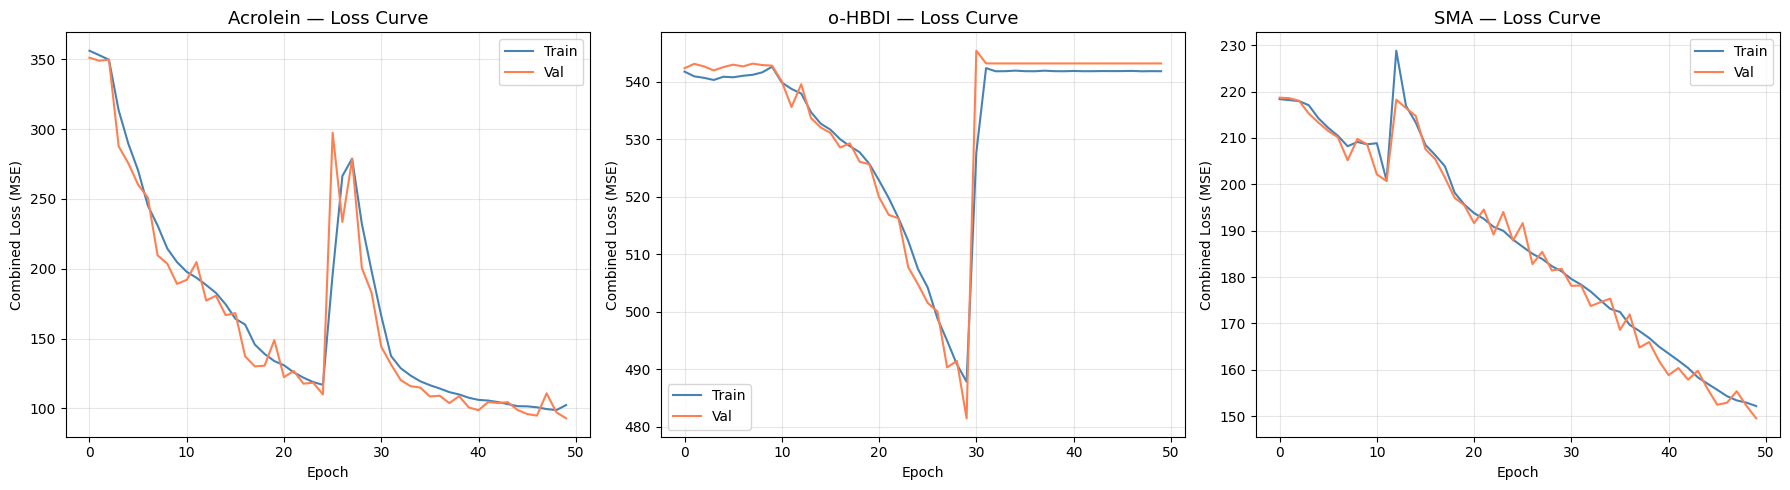

In [ ]:
loss_data = {
    "Acrolein": (train_losses_acrolein, val_losses_acrolein),
    "o-HBDI":   (train_losses_ohbdi,   val_losses_ohbdi),
    "SMA":      (train_losses_sma,     val_losses_sma),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, (mol, (tr, va)) in zip(axes, loss_data.items()):
    ax.plot(tr, label="Train", color="steelblue")
    ax.plot(va, label="Val",   color="coral")
    ax.set_title(f"{mol} — Loss Curve", fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Combined Loss (MSE)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()

## 11. Evaluation Function (Energy + Force MAE)

In [ ]:
def evaluate_model(model, loader, stats):
    """
    Evaluate model on a DataLoader.
    Returns dicts with true/predicted energies & forces (in normalised units),
    plus MAE values.
    """
    model.eval()

    true_E, pred_E = [], []
    true_F, pred_F = [], []

    for pos, energy, true_force, z in tqdm(loader, desc="Evaluating", leave=False):
        pos        = pos.to(device)
        energy     = energy.to(device)
        true_force = true_force.to(device)
        z          = z.to(device)

        pos_g = pos.clone().requires_grad_(True)
        pred_energy = model(pos_g, z)
        pred_force  = compute_forces(pred_energy, pos_g)

        true_E.extend(energy.cpu().detach().numpy().flatten())
        pred_E.extend(pred_energy.cpu().detach().numpy().flatten())
        true_F.extend(true_force.cpu().numpy().flatten())
        pred_F.extend(pred_force.cpu().detach().numpy().flatten())

    mae_e = mean_absolute_error(true_E, pred_E)
    mae_f = mean_absolute_error(true_F, pred_F)

    return {
        "true_E": np.array(true_E),
        "pred_E": np.array(pred_E),
        "true_F": np.array(true_F),
        "pred_F": np.array(pred_F),
        "mae_E":  mae_e,
        "mae_F":  mae_f,
    }


print("Evaluation function defined.")

Evaluation function defined.


In [ ]:
results = {}

for mol, model in [("acrolein", model_acrolein), ("ohbdi", model_ohbdi), ("sma", model_sma)]:
    print(f"\nEvaluating {mol}...")
    res = evaluate_model(model, all_loaders[mol]["test"], all_stats[mol])
    results[mol] = res
    print(f"  Energy MAE (normalised): {res['mae_E']:.4f}")
    print(f"  Force  MAE (normalised): {res['mae_F']:.4f}")


Evaluating acrolein...


  Energy MAE (normalised): 4.5905
  Force  MAE (normalised): 14.8968

Evaluating ohbdi...


  Energy MAE (normalised): 0.7245
  Force  MAE (normalised): 46.2523

Evaluating sma...


  Energy MAE (normalised): 3.2064
  Force  MAE (normalised): 24.8681


## 12. Parity Plots — Energy & Force

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


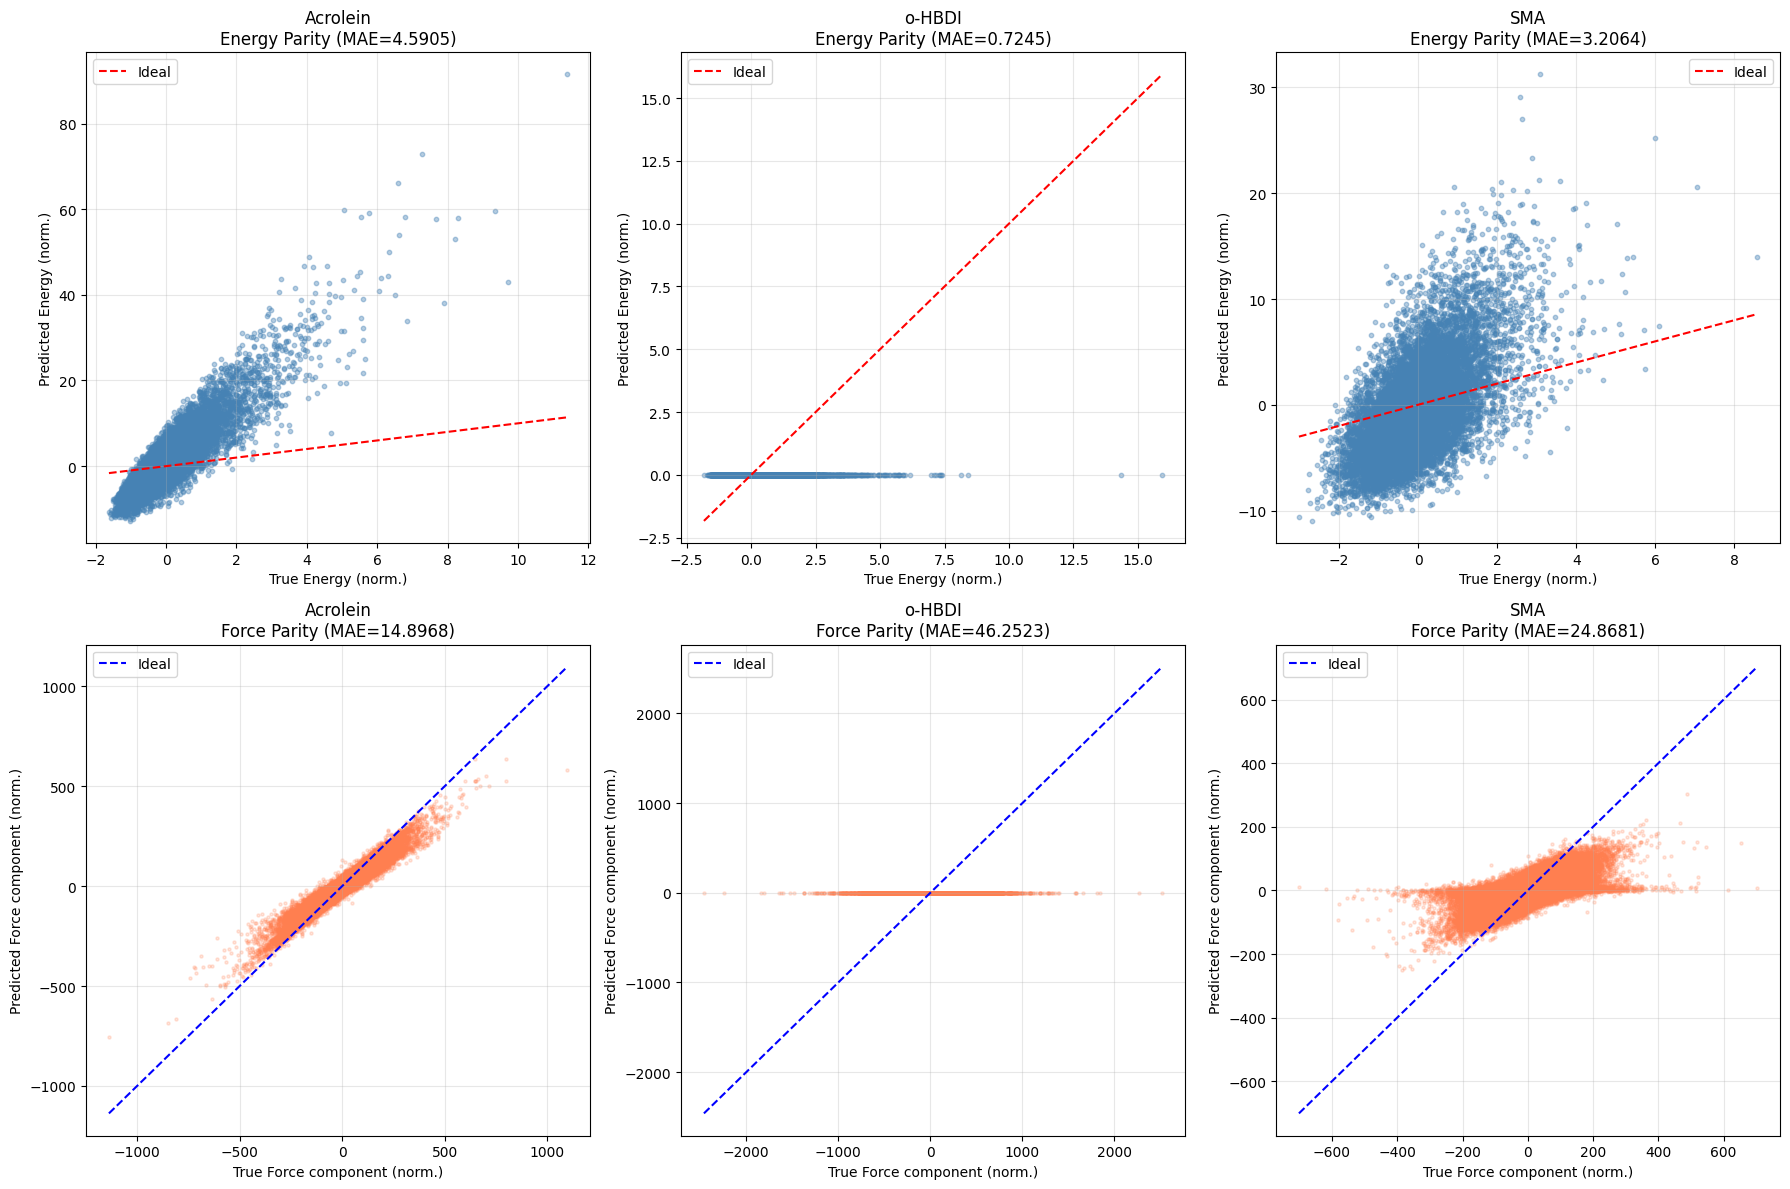

In [ ]:
mol_labels = {"acrolein": "Acrolein", "ohbdi": "o-HBDI", "sma": "SMA"}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for col, mol in enumerate(["acrolein", "ohbdi", "sma"]):
    res   = results[mol]
    label = mol_labels[mol]

    # --- Energy parity ---
    ax = axes[0, col]
    ax.scatter(res["true_E"], res["pred_E"], alpha=0.4, s=10, color="steelblue")
    lo, hi = min(res["true_E"]), max(res["true_E"])
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1.5, label="Ideal")
    ax.set_title(f"{label}\nEnergy Parity (MAE={res['mae_E']:.4f})", fontsize=12)
    ax.set_xlabel("True Energy (norm.)")
    ax.set_ylabel("Predicted Energy (norm.)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --- Force parity ---
    ax = axes[1, col]
    ax.scatter(res["true_F"], res["pred_F"], alpha=0.2, s=5, color="coral")
    lo, hi = min(res["true_F"]), max(res["true_F"])
    ax.plot([lo, hi], [lo, hi], "b--", linewidth=1.5, label="Ideal")
    ax.set_title(f"{label}\nForce Parity (MAE={res['mae_F']:.4f})", fontsize=12)
    ax.set_xlabel("True Force component (norm.)")
    ax.set_ylabel("Predicted Force component (norm.)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("parity_plots.png", dpi=150)
plt.show()

## 13. Cis/Trans Isomer Analysis

The key question: **Can PaiNN distinguish and correctly rank the energies of cis vs. trans isomers?**

### Strategy
We identify cis and trans configurations by computing a **dihedral (torsion) angle** around the C=C bond (or the relevant bond for each molecule). Configurations near 0° are *cis*, those near 180° are *trans*.

We then compare the **mean predicted energy** of each isomer class against the **mean true energy**.

In [ ]:
def dihedral_angle(p0, p1, p2, p3):
    """
    Compute the dihedral angle (degrees) defined by four points p0-p1-p2-p3.
    Uses the Praxeolitic formula (vectorised over a batch of configs).

    Args:
        p0, p1, p2, p3 : np.ndarray of shape (n_configs, 3)
    Returns:
        angles : np.ndarray of shape (n_configs,)  in degrees [-180, 180]
    """
    b0 = p0 - p1
    b1 = p2 - p1
    b2 = p3 - p2

    b1_norm = b1 / (np.linalg.norm(b1, axis=-1, keepdims=True) + 1e-8)

    v = b0 - (b0 * b1_norm).sum(-1, keepdims=True) * b1_norm
    w = b2 - (b2 * b1_norm).sum(-1, keepdims=True) * b1_norm

    x = (v * w).sum(-1)
    y = (np.cross(b1_norm, v) * w).sum(-1)

    return np.degrees(np.arctan2(y, x))


# ----------------------------------------------------------------
# Atom indices for the C=C-C=O dihedral in Acrolein:
#   Acrolein (CH2=CH-CHO) has atoms: C(0), C(1), C(2), O(3), H...
#   Standard ordering in WS22: C-C=C and then C=O
#   Dihedral: O=C-C=C  →  atoms 3-2-1-0  (adjust if your Z ordering differs)
#
# For o-HBDI and SMA the relevant dihedral is around the exocyclic C=C bond.
# The indices below are reasonable defaults — verify against your Z arrays.
# ----------------------------------------------------------------

DIHEDRAL_ATOMS = {
    # (i0, i1, i2, i3) — the four atoms defining the torsion
    "acrolein": (0, 1, 2, 3),   # C-C-C=O dihedral (cis ~0°, trans ~180°)
    "ohbdi":    (0, 1, 2, 3),   # adjust to the exocyclic C=C torsion
    "sma":      (0, 1, 2, 3),   # adjust to the relevant torsion
}

print("Dihedral function defined.")
print("NOTE: verify DIHEDRAL_ATOMS indices against your Z arrays!")

Dihedral function defined.
NOTE: verify DIHEDRAL_ATOMS indices against your Z arrays!


In [ ]:
# Print atom ordering for each molecule so you can confirm dihedral indices
for mol, mol_data in datasets.items():
    Z = mol_data["Z"]
    # Map atomic numbers to element symbols
    Z_to_sym = {1: "H", 6: "C", 7: "N", 8: "O", 16: "S", 9: "F"}
    symbols = [Z_to_sym.get(z, str(z)) for z in Z]
    print(f"{mol}: {list(enumerate(symbols))}")

acrolein: [(0, 'C'), (1, 'O'), (2, 'C'), (3, 'C'), (4, 'H'), (5, 'H'), (6, 'H'), (7, 'H')]
ohbdi: [(0, 'C'), (1, 'C'), (2, 'C'), (3, 'C'), (4, 'C'), (5, 'C'), (6, 'H'), (7, 'H'), (8, 'H'), (9, 'H'), (10, 'C'), (11, 'H'), (12, 'C'), (13, 'C'), (14, 'C'), (15, 'O'), (16, 'O'), (17, 'N'), (18, 'N'), (19, 'H'), (20, 'H'), (21, 'H')]
sma: [(0, 'O'), (1, 'N'), (2, 'C'), (3, 'C'), (4, 'C'), (5, 'C'), (6, 'C'), (7, 'C'), (8, 'C'), (9, 'C'), (10, 'H'), (11, 'H'), (12, 'H'), (13, 'H'), (14, 'H'), (15, 'H'), (16, 'H'), (17, 'H'), (18, 'H')]


In [ ]:
def analyse_cis_trans(mol, model, mol_data, stats, dihedral_atoms, threshold=60.0):
    """
    For all configurations in the dataset:
      1. Compute the torsion angle.
      2. Label as cis (|angle| < threshold) or trans (|angle| > 180-threshold).
      3. Compare mean true vs. predicted normalised energy for each isomer.
    """
    R, E_raw, Z = mol_data["R"], mol_data["E"], mol_data["Z"]
    E_mean, E_std = stats["E_mean"], stats["E_std"]
    E_norm = (E_raw - E_mean) / E_std

    i0, i1, i2, i3 = dihedral_atoms
    angles = dihedral_angle(R[:, i0], R[:, i1], R[:, i2], R[:, i3])

    cis_mask   = np.abs(angles) < threshold
    trans_mask = np.abs(np.abs(angles) - 180) < threshold
    other_mask = ~(cis_mask | trans_mask)

    print(f"\n--- {mol.upper()} cis/trans distribution ---")
    print(f"  Cis   (|θ| < {threshold}°):       {cis_mask.sum():5d} configs")
    print(f"  Trans (|θ-180| < {threshold}°):   {trans_mask.sum():5d} configs")
    print(f"  Other (intermediate):         {other_mask.sum():5d} configs")

    # Predict energies for all configs
    model.eval()
    all_pred_E = []
    z_tensor   = torch.tensor(Z, dtype=torch.long).unsqueeze(0).to(device)  # (1, n_atoms)
    batch_size = 64

    for start in range(0, len(R), batch_size):
        batch_R = torch.tensor(R[start:start+batch_size], dtype=torch.float32).to(device)
        batch_z = z_tensor.expand(batch_R.shape[0], -1)
        with torch.no_grad():
            pred_e = model(batch_R, batch_z)
        all_pred_E.extend(pred_e.cpu().numpy().flatten())

    all_pred_E = np.array(all_pred_E)

    summary = {}
    for label, mask in [("cis", cis_mask), ("trans", trans_mask)]:
        if mask.sum() == 0:
            print(f"  WARNING: no {label} configs found — check dihedral indices!")
            continue
        true_mean = E_norm[mask].mean()
        pred_mean = all_pred_E[mask].mean()
        print(f"  {label:5s} | True E (norm) = {true_mean:+.4f} | Pred E (norm) = {pred_mean:+.4f}")
        summary[label] = {"true": true_mean, "pred": pred_mean}

    # Check whether the model correctly orders cis vs. trans
    if "cis" in summary and "trans" in summary:
        true_order = "cis < trans" if summary["cis"]["true"] < summary["trans"]["true"] else "trans < cis"
        pred_order = "cis < trans" if summary["cis"]["pred"] < summary["trans"]["pred"] else "trans < cis"
        correct = "✅ CORRECT" if true_order == pred_order else "❌ INCORRECT"
        print(f"  True energy ordering: {true_order}")
        print(f"  Pred energy ordering: {pred_order}  →  {correct}")

    return angles, cis_mask, trans_mask, all_pred_E, E_norm


cis_trans_results = {}
for mol, model in [("acrolein", model_acrolein), ("ohbdi", model_ohbdi), ("sma", model_sma)]:
    angles, cis_mask, trans_mask, all_pred_E, E_norm = analyse_cis_trans(
        mol, model, datasets[mol], all_stats[mol], DIHEDRAL_ATOMS[mol]
    )
    cis_trans_results[mol] = {
        "angles": angles,
        "cis_mask": cis_mask,
        "trans_mask": trans_mask,
        "all_pred_E": all_pred_E,
        "E_norm": E_norm,
    }


--- ACROLEIN cis/trans distribution ---
  Cis   (|θ| < 60.0°):       54650 configs
  Trans (|θ-180| < 60.0°):   57871 configs
  Other (intermediate):          7479 configs
  cis   | True E (norm) = +0.2779 | Pred E (norm) = +1.6332
  trans | True E (norm) = -0.2513 | Pred E (norm) = +0.8123
  True energy ordering: trans < cis
  Pred energy ordering: trans < cis  →  ✅ CORRECT

--- OHBDI cis/trans distribution ---
  Cis   (|θ| < 60.0°):       120000 configs
  Trans (|θ-180| < 60.0°):       0 configs
  Other (intermediate):             0 configs
  cis   | True E (norm) = +0.0015 | Pred E (norm) = -0.0001

--- SMA cis/trans distribution ---
  Cis   (|θ| < 60.0°):       56674 configs
  Trans (|θ-180| < 60.0°):   58404 configs
  Other (intermediate):          4962 configs
  cis   | True E (norm) = +0.1885 | Pred E (norm) = -0.1632
  trans | True E (norm) = -0.1712 | Pred E (norm) = -0.2651
  True energy ordering: trans < cis
  Pred energy ordering: trans < cis  →  ✅ CORRECT


## 14. Cis/Trans Visualisation: Torsion vs. Energy

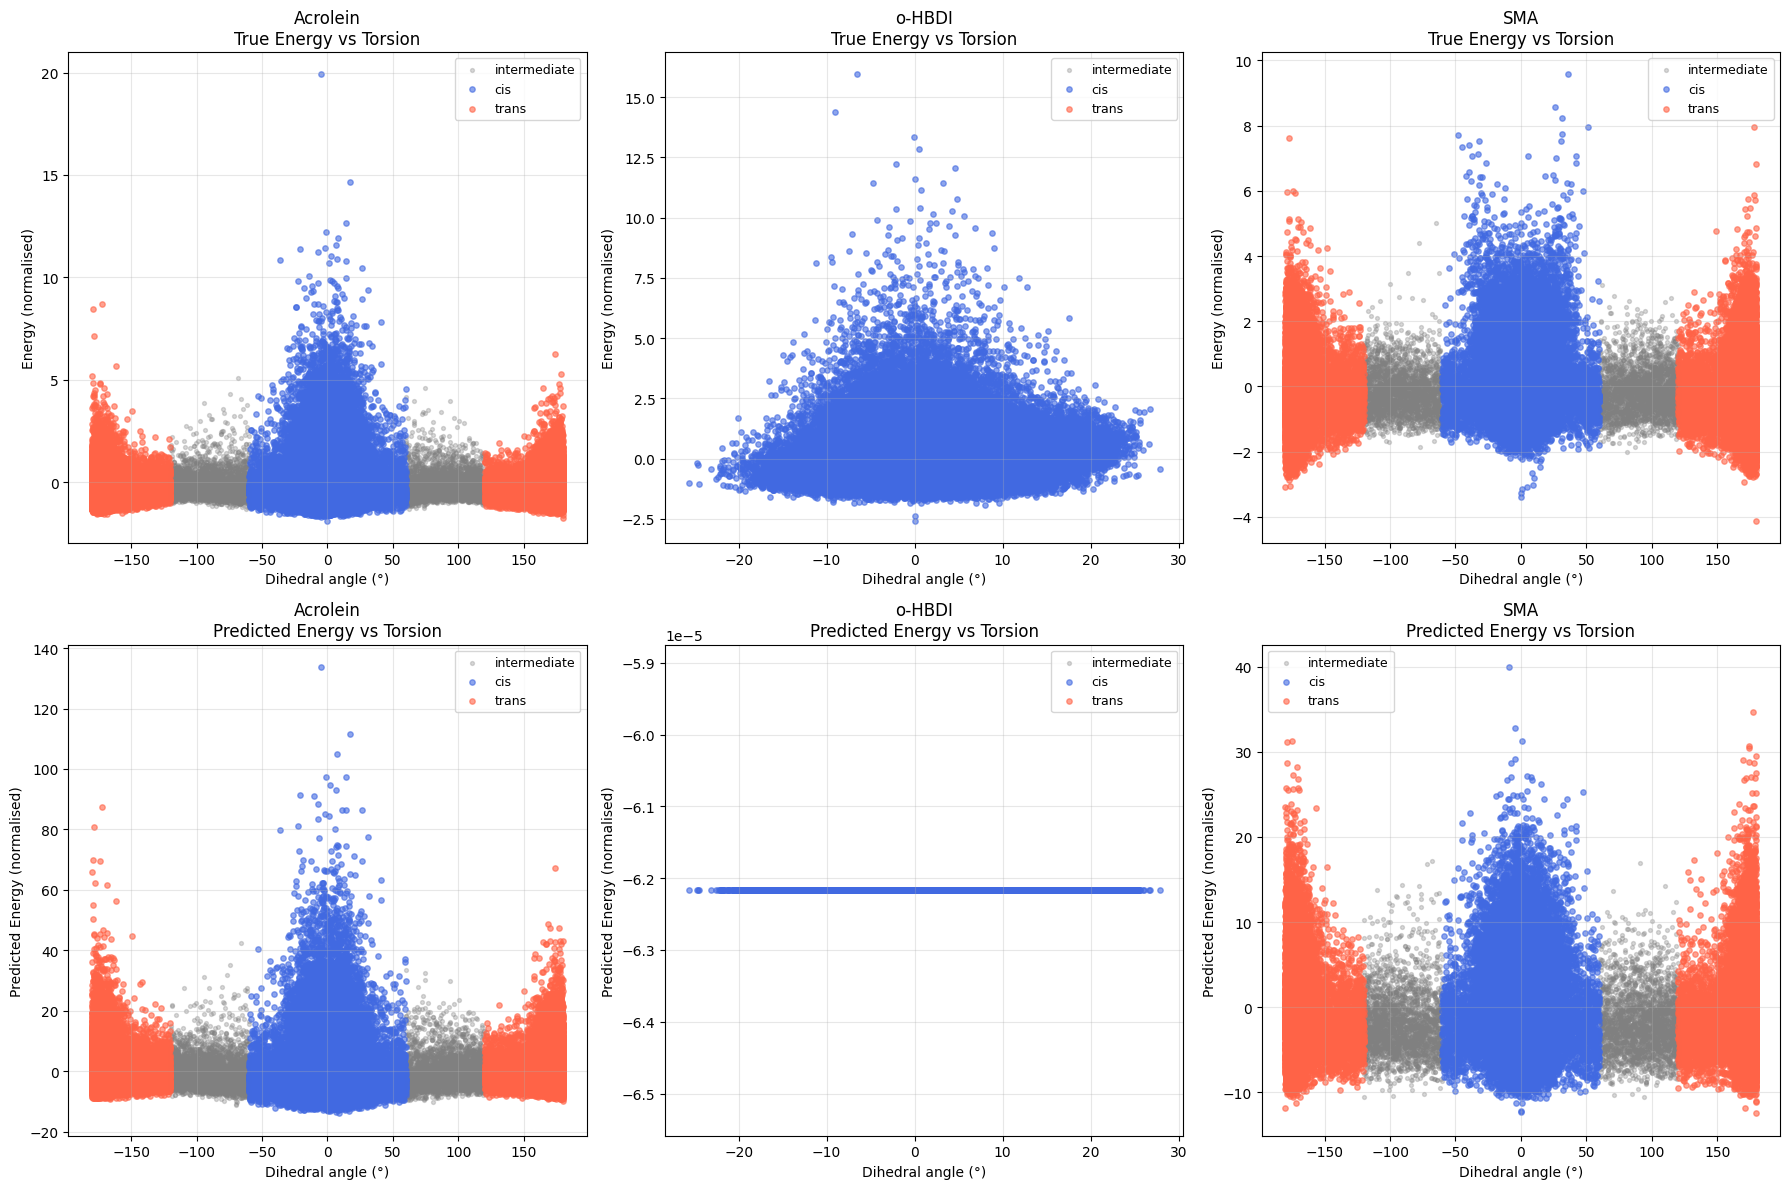

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for col, mol in enumerate(["acrolein", "ohbdi", "sma"]):
    r   = cis_trans_results[mol]
    lbl = mol_labels[mol]

    angles     = r["angles"]
    E_norm     = r["E_norm"]
    all_pred_E = r["all_pred_E"]
    cis_mask   = r["cis_mask"]
    trans_mask = r["trans_mask"]

    # Row 0: True energy vs dihedral
    ax = axes[0, col]
    other_mask = ~(cis_mask | trans_mask)
    ax.scatter(angles[other_mask], E_norm[other_mask],     s=8,  alpha=0.3, color="grey",   label="intermediate")
    ax.scatter(angles[cis_mask],   E_norm[cis_mask],       s=15, alpha=0.6, color="royalblue", label="cis")
    ax.scatter(angles[trans_mask], E_norm[trans_mask],     s=15, alpha=0.6, color="tomato",    label="trans")
    ax.set_title(f"{lbl}\nTrue Energy vs Torsion", fontsize=12)
    ax.set_xlabel("Dihedral angle (°)")
    ax.set_ylabel("Energy (normalised)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Row 1: Predicted energy vs dihedral
    ax = axes[1, col]
    ax.scatter(angles[other_mask], all_pred_E[other_mask], s=8,  alpha=0.3, color="grey",      label="intermediate")
    ax.scatter(angles[cis_mask],   all_pred_E[cis_mask],   s=15, alpha=0.6, color="royalblue", label="cis")
    ax.scatter(angles[trans_mask], all_pred_E[trans_mask], s=15, alpha=0.6, color="tomato",    label="trans")
    ax.set_title(f"{lbl}\nPredicted Energy vs Torsion", fontsize=12)
    ax.set_xlabel("Dihedral angle (°)")
    ax.set_ylabel("Predicted Energy (normalised)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cistrans_torsion_energy.png", dpi=150)
plt.show()

## 15. Save Models

In [ ]:
torch.save(model_acrolein.state_dict(), "painn_acrolein.pt")
torch.save(model_ohbdi.state_dict(),    "painn_ohbdi.pt")
torch.save(model_sma.state_dict(),      "painn_sma.pt")

print("Models saved: painn_acrolein.pt, painn_ohbdi.pt, painn_sma.pt")

Models saved: painn_acrolein.pt, painn_ohbdi.pt, painn_sma.pt
